# **Project : Product Return Prediction**

## Introduction
In this project, we focus on understanding the reasons behind product returns and predict whether a product will be returned. Our primary goal is to provide actionable insights to retailers rather than achieving the maximum model accuracy. By identifying patterns and factors that leads to returns, we aim to help businesses to reduce return rates and associated costs.

## Problem Statement
To Predict the likelihood of a product being returned based on various features such as product category, price and customer demographics. The goal of this project is to provide insights into the factors that contribute to product returns, enabling reatilers to make informed decisions and improve their return policies and customer experience.

## Business Problem
In the retail industry, product returns are a significant challenge, impacting profitablity and customer satisfaction. Understanding the reasons behind returns can help retailers improve their products, services and customer experience.     

## Mapping the Real-World Problem to a Machine Learning Problem
**It is a machine learning binary classification problem where we predict whether a order will be returned or not. By analyzing various order features, its aim to help businesses reduce return rates and improve customer satisfaction.**

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import sklearn
from scipy import stats
import kaggle
from pathlib import Path
import sidetable

### Dispaly Settings

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 1000)
import warnings
warnings.filterwarnings('ignore')


### Data Ingestion and Exploration

In [3]:
path = Path.cwd()
paths = path.parent.joinpath('data', 'raw')

file = []
for p in paths.glob('*'):
    file.append(p.name)

print(file)

['.gitkeep', 'Global Superstore.xls']


In [4]:
#find all excel files name in .xls sheet
df = pd.read_excel(paths/'Global Superstore.xls',sheet_name=None)
df.keys()

dict_keys(['Orders', 'Returns', 'People'])

In [5]:
orders = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Orders')
return_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Returns')
people_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='People')
display(orders.tail(1),
    return_df.tail(1),
    people_df.tail(1))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51289,6147,MX-2012-134460,2012-05-22,2012-05-26,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,Nicaragua,NaN,LATAM,Central,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.38,3,0.0,1.8,0.002,High


,Returned,Order ID,Market
1172,Yes,CA-2014-168193,United States


,Person,Region
12,Alejandro Ballentine,Southeast Asia


In [6]:
order_df = orders.copy()
display('Orders shape :',order_df.shape, 
        'Returns shape', return_df.shape, 
        'People shape',people_df.shape)

'Orders shape :'

(51290, 24)

'Returns shape'

(1173, 3)

'People shape'

(13, 2)

In [7]:
# remove whitespaces from column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.strip()

In [8]:
# Lets lower case all column names
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.lower()


In [9]:
# lets check the data types of the columns
order_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row id          51290 non-null  int64         
 1   order id        51290 non-null  object        
 2   order date      51290 non-null  datetime64[ns]
 3   ship date       51290 non-null  datetime64[ns]
 4   ship mode       51290 non-null  object        
 5   customer id     51290 non-null  object        
 6   customer name   51290 non-null  object        
 7   segment         51290 non-null  object        
 8   city            51290 non-null  object        
 9   state           51290 non-null  object        
 10  country         51290 non-null  object        
 11  postal code     9994 non-null   float64       
 12  market          51290 non-null  object        
 13  region          51290 non-null  object        
 14  product id      51290 non-null  object        
 15  ca

In [10]:
return_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   returned  1173 non-null   object
 1   order id  1173 non-null   object
 2   market    1173 non-null   object
dtypes: object(3)
memory usage: 27.6+ KB


In [11]:
people_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   person  13 non-null     object
 1   region  13 non-null     object
dtypes: object(2)
memory usage: 340.0+ bytes


**Dataset Summary**

**The Global Superstore dataset contains three sheets: Orders, Returns and People.**
    
- **The Orders sheet contains information about customer orders, including order ID, customer ID, demographic details ,product details and sales data.**    
- **The Returns sheet contains information about returned orders, including order ID and market details.**    
- **The people sheet contains information about customers, including customer name and demographic details.**
    
**The data spans a robust four-year period from 2011 to 2015 . This dataset contains a vast array of order-related information, offering insights into retail operations across 147 countries.**


Brief description of columns:

- **Order Information**

    - **Order ID** – Unique identifier for each order.

    - **Order Date** – Date when the order was placed.

    - **Ship Date** – Date when the order was shipped.

    - **Ship Mode** – Shipping method (e.g., Standard Class, Second Class, First Class, Same Day).

- **Customer Information**

    - **Customer ID** – Unique identifier for each customer.

    - **Customer Name** – Name of the customer.

    - **Segment** – Customer segment (Consumer, Corporate, Home Office).

    - **Country** – Country where the customer is located.

    - **City / State / Region** – Geographic details of the customer.

- **Product Information**

    - **Product ID** – Unique identifier for each product.

    - **Category** – Broad product category (Furniture, Office Supplies, Technology).

    - **Sub-Category** – More specific product type (e.g., Chairs, Phones, Binders).

    - **Product Name** – Name/description of the product.

- **Sales & Profit Metrics**

    - **Sales** – Revenue generated from the order.

    - **Quantity** – Number of units sold.

    - **Discount** – Discount applied to the order.

    - **Profit** – Profit earned from the order after costs.

- **Geographic & Managerial**

    - **Region** – Region of the world (e.g., Asia, Europe, US).

    - **Postal Code** – Postal/ZIP code of the customer.

    - **Market** – Market grouping (e.g., APAC, EMEA).

- **Returns (separate sheet)**

    - **Returned** – Indicates whether an order was returned.

## **Number Formatting and Category Consistency**

In [12]:
order_df.columns = order_df.columns.str.replace(' ', '_')
print(order_df.columns)
return_df.columns = return_df.columns.str.replace(' ', '_')
print(return_df.columns)

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub-category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority'],
      dtype='object')
Index(['returned', 'order_id', 'market'], dtype='object')


In [13]:
dtype_df = pd.DataFrame({
    'dtype': order_df.dtypes,
    'nunique': order_df.nunique(),
    'unique' : [order_df[col].unique() for col in order_df.columns]
}, index=order_df.columns)
dtype_df

,dtype,nunique,unique
row_id,int64,51290,"[32298, 26341, 25330, 13524, 47221, 22732, 305..."
order_id,object,25035,"[CA-2012-124891, IN-2013-77878, IN-2013-71249,..."
order_date,datetime64[ns],1430,"[2012-07-31 00:00:00, 2013-02-05 00:00:00, 201..."
ship_date,datetime64[ns],1464,"[2012-07-31 00:00:00, 2013-02-07 00:00:00, 201..."
ship_mode,object,4,"[Same Day, Second Class, First Class, Standard..."
customer_id,object,1590,"[RH-19495, JR-16210, CR-12730, KM-16375, RH-94..."
customer_name,object,795,"[Rick Hansen, Justin Ritter, Craig Reiter, Kat..."
segment,object,3,"[Consumer, Corporate, Home Office]"
city,object,3636,"[New York City, Wollongong, Brisbane, Berlin, ..."
state,object,1094,"[New York, New South Wales, Queensland, Berlin..."


In [14]:
def highlight_zero_neg(val):
    if val == 0:
        return 'background-color: yellow; color: black'   # zero values highlighted in yellow
    elif val < 0:
        return 'background-color: red; color: white'    # negative values highlighted in red
    else:
        return ''  # no highlight for positive values

In [15]:
# Number Formatting and data description for numerical columns
df_desc = order_df.describe(exclude='object')
display(df_desc.style.applymap(highlight_zero_neg, subset = df_desc.select_dtypes(include='number').columns))


,row_id,order_date,ship_date,postal_code,sales,quantity,discount,profit,shipping_cost
count,51290.000000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.500000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.000000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.250000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.500000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.750000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.000000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.291990,nan,nan,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


**NOTEs**:
- **Discount**: The discount column has a lot of zero values, which might indicate that many orders were made without any discount. Or, there is any other reason we need to investigate furthur.
- **Profit**: The profit column has a negative value which indicates that there are some orders that resulted in a loss and profit value is zero as well which inidicates that there are some orders that did not generate any profit, or these values are some error need to investigate furthur.


In [16]:
order_df.describe(include='object')

,order_id,ship_mode,customer_id,customer_name,segment,city,state,country,market,region,product_id,category,sub-category,product_name,order_priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4
top,CA-2014-100111,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium
freq,14,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433


### **Missing Value Analysis**

In [17]:
missing_df = order_df.stb.missing()
missing_df[missing_df['missing']!=0]

,missing,total,percent
postal_code,41296,51290,80.51472


In [18]:
return_df.stb.missing()

,missing,total,percent
returned,0,1173,0.0
order_id,0,1173,0.0
market,0,1173,0.0


- **order_df has only ~81% missing values in postal code column. We can impute it with mode or drop it as well since it is not a key column for analysis.**

- **return_df has no missing values.**

- **Lets explore return dataframe and transform return_df column to bool type and examine if market category is clean(no two or more names for same market, etc.)**

In [19]:
def clean_return_df(raw_df):
    clean_df = raw_df.copy()
    # transform return column to bool type
    clean_df['returned'] = clean_df['returned'].map({'Yes': True, 'No': False})
    # since order has 'US' market only but returns has 'Unites States' market name, we will change 'United States' to 'US'
    clean_df['market'].replace({'United States': 'US'}, inplace=True)
    return clean_df


In [20]:
# let's clean return_df and store as returns
returns = clean_return_df(return_df)
returns.head()

,returned,order_id,market
0,True,MX-2013-168137,LATAM
1,True,US-2011-165316,LATAM
2,True,ES-2013-1525878,EU
3,True,CA-2013-118311,US
4,True,ES-2011-1276768,EU


### **Duplicate Data**

In [21]:
dfs = {
    "orders" : order_df,
    "returns" : returns,
    "people" : people_df
}
for name, df in dfs.items():
    print(f"Duplicate data in {name} data : {df.duplicated().sum()}", '\n')

Duplicate data in orders data : 0 

Duplicate data in returns data : 0 

Duplicate data in people data : 0 



**No Duplicate observations in any above data.**

### **Merge orders and returns data for analysis**

In [22]:
(order_df.columns).intersection(returns.columns)

Index(['order_id', 'market'], dtype='object')

In [23]:
order_merged = pd.merge(order_df, returns, on =['order_id', 'market'], how='left')
order_merged.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,postal_code,market,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,returned
0,32298,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical,NaN
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical,True


In [24]:
# About order_merged data
print(f"Order Return Merge Data : {order_merged.shape}", '\n')
print(f"Data of 'returned' column type : {order_merged['returned'].dtype}",'\n')
print(f"Data counts of 'returned' column : {order_merged['returned'].value_counts(dropna=False)}")

Order Return Merge Data : (51290, 25) 

Data of 'returned' column type : object 

Data counts of 'returned' column : returned
NaN     48247
True     3043
Name: count, dtype: int64


In [25]:
order_merged['returned'] = order_merged['returned'].fillna(False)
order_merged['returned'].value_counts()

returned
False    48247
True      3043
Name: count, dtype: int64

In [26]:
# clean returned column
order_merged['returned_new'] = order_merged['returned'].map(lambda x: 0 if x is False else 1)

# Lets check if our transformation worked
order_merged['returned_new'].value_counts(dropna=False)


returned_new
0    48247
1     3043
Name: count, dtype: int64

## **What are Overall Trends of **Sales and Profit**?**

#### **KPIs (Key Performance Indicators)**

kpis = {
    'total_sales' : order_df['sales'].sum().round(2),
    'total_profit' : order_df['profit'].sum().round(2),
    'profit_margin': (order_df['profit'].sum() / order_df['sales'].sum()) * 100,
    'total_orders': order_df['order_id'].nunique(),
    'avg_order_value': order_df['sales'].sum() / order_df['order_id'].nunique(),
    'total_quantity_sold': order_df['quantity'].sum(),
    'total_customers': order_df['customer_id'].nunique()
    }

kpi_df = pd.DataFrame.from_dict([kpis])
kpi_df

## **Total Revenue and Gross Margin**

In [27]:
# Requirement gatheing of data for seasonal analysis
print(f"Order Date data type: {order_merged['order_date'].dtype}")
print(order_merged['order_date'].head(1))


Order Date data type: datetime64[ns]
0   2012-07-31
Name: order_date, dtype: datetime64[ns]


In [28]:
# Create new dimensions from order date column like year, month, week, dayofyear, etc. for seasonal trend
order_merged['order_year'] = order_merged['order_date'].dt.year
order_merged['order_month'] = order_merged['order_date'].dt.month
order_merged['order_week'] = order_merged['order_date'].dt.isocalendar().week
order_merged['order_dayofyear'] = order_merged['order_date'].dt.dayofyear   
order_merged['order_quarter'] = order_merged['order_date'].dt.quarter
display("Newly created date dimensions:", order_merged[['order_date','order_year', 'order_month', 'order_week', 'order_dayofyear', 'order_quarter']].head(4))


'Newly created date dimensions:'

,order_date,order_year,order_month,order_week,order_dayofyear,order_quarter
0,2012-07-31,2012,7,31,213,3
1,2013-02-05,2013,2,6,36,1
2,2013-10-17,2013,10,42,290,4
3,2013-01-28,2013,1,5,28,1


In [29]:
# requirement gathering data
# consider order_year, market, sales, profit, returned columns for analysis

# 1. Group By year and market
# profit exclude returns
order_merged['profit_exclude_returns'] = order_merged['profit'].where(order_merged['returned']==False,0)
sales_profit_df = order_merged.groupby(['order_year', 'market']).agg(
    sales = ('sales', 'sum'),
    profit = ('profit_exclude_returns', 'sum') 
)
# 2. Compute margin
sales_profit_df['profit_margin'] = (sales_profit_df['profit'] / sales_profit_df['sales']).round(2)

# 3. Round sales and profit
sales_profit_df['sales'] = sales_profit_df['sales'].round(2)
sales_profit_df['profit'] = sales_profit_df['profit'].round(2)

# 4. Reset index and sort
revenue_margin = sales_profit_df.reset_index().sort_values(by = ['order_year', 'sales'], ascending=[True, False])

display(revenue_margin.head(10))


,order_year,market,sales,profit,profit_margin
0,2011,APAC,639245.26,71591.59,0.11
6,2011,US,484247.50,49073.30,0.10
4,2011,EU,478743.28,60508.18,0.13
5,2011,LATAM,385098.16,33055.28,0.09
3,2011,EMEA,136420.32,5280.03,0.04
1,2011,Africa,127187.27,10944.11,0.09
2,2011,Canada,8509.11,1807.08,0.21
7,2012,APAC,762719.33,80125.18,0.11
11,2012,EU,655461.69,75793.98,0.12
13,2012,US,470532.51,57196.57,0.12


# visualize the result data
scale = revenue_margin['sales'].mean()
offset = revenue_margin['sales'].mean()

fig, ax = plt.subplots(figsize=(12, 7))

# --- Bar plot for sales by market and year ---
sns.barplot(
    data=revenue_margin,
    x='market', y='sales', hue='order_year',
    dodge=True, ax=ax,
    palette={2011:'#58508d', 2012:'#bc5090', 2013:'#ff6361', 2014:'#ffa600'}
)
# --- Bar plot for profit ---
sns.barplot(
    data=revenue_margin,
    x='market', y='profit',
    color='#003f5c', dodge=True, ax=ax,
    label='Profit'
)

plt.show()

# --- Bar plot for profit ---
sns.barplot(
    data=revenue_margin,
    x='market', y='profit',
    color='#003f5c', dodge=True, ax=ax,
    label='Profit'
)

# --- Line + points for margin ---
for i, row in revenue_margin.iterrows():
    y_val = offset + row['margin'] * scale
    ax.plot(row['market'], y_val, 'o-', color='black')
    ax.text(row['market'], y_val, f"{row['margin']:.0%}",
            ha='center', va='bottom', fontsize=8)

# --- Vertical dotted lines between markets ---
for i in range(1, len(revenue_margin['market'].unique())):
    ax.axvline(i-0.5, linestyle='dotted', color='gray')

# --- Y-axis formatting ---
ax.set_ylim(0, 1300000)
ax.set_yticks(range(0, 1300001, 100000))
ax.set_yticklabels([f"{y//1000}K" for y in range(0, 1300001, 100000)])
ax.set_ylabel("Sales & Profit, $")

# --- Title and labels ---
ax.set_title("Total Revenue and Gross Margin")
ax.set_xlabel("Market")

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Sales", loc="upper center")

sns.despine()
plt.show()

##### **Seasonal Sales Trend**

##### **1. What data do you have?**

To detect seasonality, the dataset should include at least:

- **A date or time column**: This is essential for identifying seasonal patterns. The date column should cover multiple years to capture recurring trends.
- **Inventory related columns**: Columns such as sales, profit, or stock levels are crucial for analyzing seasonal fluctuations in order and return.
- **Possibly Product or category columns**: These can help in understanding if certain products or categories exhibit seasonal trends.


Will analyze daily, weekly, monthly sales trends across years to identify seasonal patterns and peak sales periods. And, visualize which seasonal trend is more clearer and relevant . Total sum or mean of sales seems appropriate for good summary.

order_df.columns

### **Total Gross & Net Revenue and YoY Profit Growth**

In [30]:
# requirement gathering data for analysis
# Aggregate by year and round values to 2 decimal places
yearly = order_merged.groupby(['order_year']).agg(
    net_sales = ('sales', lambda x: x[~(order_merged.loc[x.index, 'returned'])].sum()),
    return_sales = ('sales', lambda x: x[order_merged.loc[x.index, 'returned']].sum()),
    net_profit = ('profit', lambda x: x[~(order_merged.loc[x.index, 'returned'])].sum())
    ).reset_index().round(2)

# compute YoY profit growth
yearly['yoy_profit_growth'] = yearly['net_profit'].pct_change().round(2)
display(yearly)

,order_year,net_sales,return_sales,net_profit,yoy_profit_growth
0,2011,2104950.33,154500.57,232259.57,NaN
1,2012,2500155.67,177283.03,278076.87,0.20
2,2013,3216759.73,188986.72,384269.22,0.38
3,2014,4002592.05,297273.82,454683.93,0.18


In [31]:
# Aggregate and First order by order_id
processed_df = (
    order_merged.drop_duplicates(subset=['order_id'])
    .groupby('order_id', as_index=False)
    .agg({
        'order_date': 'first',  # Equivalent to first_value(order_date)
        'sales': 'sum',         # Equivalent to sum(sales)
        'profit': 'sum',        # Equivalent to sum(profit)
        'returned': 'first'     # Equivalent to first_value(returned)
    })
    .sort_values('order_id')   # Equivalent to  First ORDER BY an Individual
    .assign(year=lambda x: pd.to_datetime(x['order_date']).dt.year)  # Extract year if needed
    .sort_values('year')       # Final ORDER BY year
)
display(processed_df.head())

,order_id,order_date,sales,profit,returned,year
0,AE-2011-9160,2011-10-03,82.674,-157.086,False,2011
22632,UP-2011-870,2011-04-30,96.420,23.100,False,2011
22633,UP-2011-9080,2011-12-16,414.720,70.500,False,2011
22634,UP-2011-9150,2011-07-18,13.470,0.660,False,2011
22635,UP-2011-960,2011-09-22,109.740,35.100,False,2011


## **Quarterly Net Revenue growth**

In [88]:
# -- Trend of quarterly revenue growth

# Aggregate by year and quarter
quarterly = (
    order_merged.groupby(['order_year', 'order_quarter'])
    .agg(
        net_sales = ('sales', lambda x: x[~(order_merged.loc[x.index, 'returned'])].sum()), # exclude returns
        gross_sales = ('sales', 'sum')
    )
).reset_index().sort_values(by=['order_year', 'order_quarter']).round(2)

# Add row number
quarterly['n'] = quarterly.reset_index().index + 1

# Create label column
quarterly['label'] = "Q" + quarterly['order_quarter'].astype(str) + "'" + quarterly['order_year'].astype(str).str[-2:]

# Computer growth rate(quarter-over-quarter growth)
quarterly['growth_rate'] = quarterly['net_sales'].pct_change().round(2)
display(quarterly.head())

,order_year,order_quarter,net_sales,gross_sales,n,label,growth_rate
0,2011,1,319740.40,335780.01,1,Q1'11,NaN
1,2011,2,444865.44,478870.98,2,Q2'11,0.39
2,2011,3,569174.72,613306.37,3,Q3'11,0.28
3,2011,4,771169.76,831493.54,4,Q4'11,0.35
4,2012,1,380496.46,399367.71,5,Q1'12,-0.51


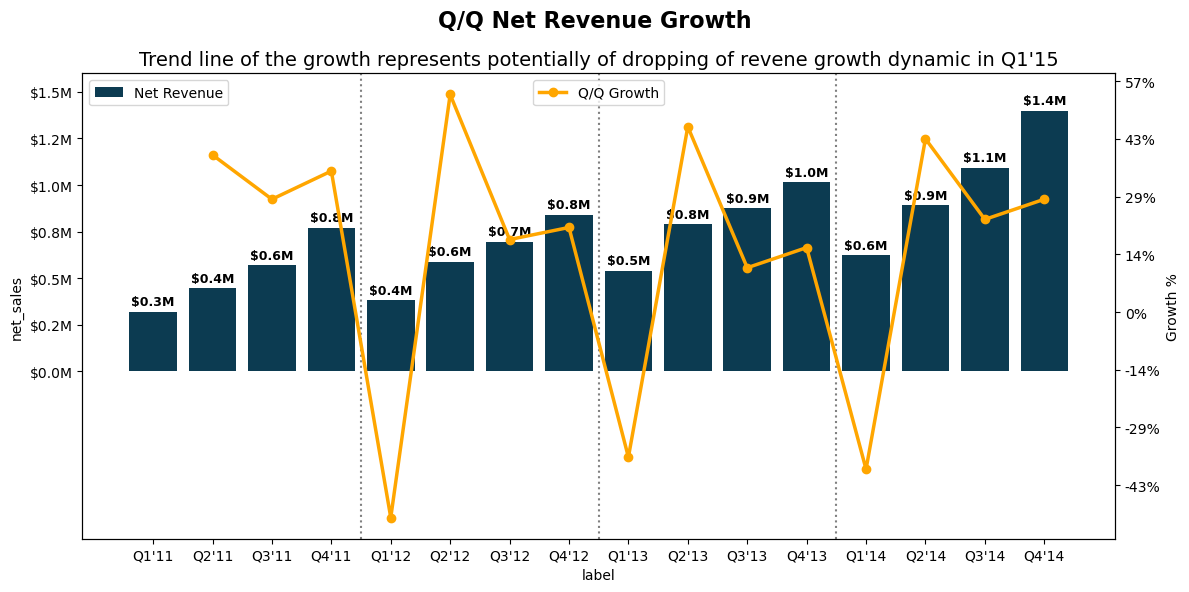

In [127]:
# --- visualization of Quarter Net Revenue Growth
# Reorder labels by 'n'
from matplotlib.ticker import FuncFormatter


quarterly = quarterly.sort_values('n')
scale = quarterly['net_sales'].max()

# Create figure and axis
fig, ax = plt.subplots(figsize=(12,6))

# bar plot for net_sales
sns.barplot(data=quarterly, x='label', y='net_sales', color = '#003f5c', ax=ax, label = 'Net Revenue')
ax.legend()
# Add text labels on bar
for i, v in enumerate(quarterly['net_sales']):
    ax.text(i, v + 20000, f"${v/1e6:.1f}M", ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot the line chart for growth
ax2 = ax.twinx()
ax2.plot(quarterly['label'], quarterly['growth_rate']*scale, color='#ffa600', marker='o', lw = 2.5, label='Q/Q Growth')
ax2.set_ylabel("Growth %")
ax2.legend()

# Format the y-axis labels
def millions(x, pos):
    return f"${x / 1e6:.1f}M"

ax.yaxis.set_major_formatter(FuncFormatter(millions))
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/scale:.0%}"))

# Set the limits and breaks for the y-axis
ax.set_ylim(-900000, 1600000)
ax.set_yticks(range(0, 1600001, 250000)) 
#ax2.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Add Vertical line:
for x in range(4, len(quarterly['label']), 4):
    ax.axvline(x = x - 0.5, ls='dotted', color='gray')

# Add labels and title
fig.suptitle("Q/Q Net Revenue Growth", fontsize=16, fontweight='bold')
ax.set_title("Trend line of the growth represents potentially of dropping of revene growth dynamic in Q1'15", fontsize=14)

# Add legend
ax.legend(loc='upper left')
ax2.legend(loc='upper center')

# Add layout
plt.tight_layout()
plt.show()

## **Profit Trends**

In [33]:
# Compute last day of month for each order date
order_merged['last_month_day'] = order_merged['order_date'] + pd.offsets.MonthEnd(0)
# Aggregate profit by 'last_month_day' (excluding returns)
monthly = (
    order_merged[order_merged['returned']==False]
    .groupby(['last_month_day'])
    .agg(
        {'profit': 'sum'}
        )
        ).reset_index().sort_values(by='last_month_day').round(2)

# Compute month-over-month profit growth
monthly['growth_rate'] = monthly['profit'].pct_change().round(2)
display(monthly.head())

,last_month_day,profit,growth_rate
0,2011-01-31,8170.08,NaN
1,2011-02-28,8504.04,0.04
2,2011-03-31,15091.52,0.77
3,2011-04-30,13175.23,-0.13
4,2011-05-31,10862.73,-0.18


## **Total number of orders and loss orders**

In [34]:
# Aggregate at market-year level (outer query)

summary = (
    order_merged
    .groupby(['market', 'order_year'],as_index=False)
    .agg(
        gross_sales = ('sales', 'sum'),
        total_order = ('order_id', 'nunique'),
        loss_order = ('order_id', lambda x: x[order_merged['profit'] < 0].nunique())
    )
    ).round(2)
display(summary.head())

,market,order_year,gross_sales,total_order,loss_order
0,APAC,2011,639245.26,966,343
1,APAC,2012,762719.33,1182,428
2,APAC,2013,974580.86,1404,526
3,APAC,2014,1209198.69,1885,717
4,Africa,2011,127187.27,382,94


## **Customer Lifetime Value (CLV)**

In [85]:
# Aggregate sales by market, segment and year
from typing import final


sales_df = (
    order_merged.groupby(['market', 'segment', 'order_year'], as_index=False)
    .agg(sales = ('sales', 'sum'))
)

# Count the customers by market, segment and year
cust_df = (
    order_merged.groupby(['market', 'segment', 'order_year'], as_index=False)
    .agg(uniq_customers = ('customer_id', 'nunique'))
)

# Merge sales and customers dataframes for customer value
merged_df = (
    sales_df
    .merge(cust_df, on = ['market', 'segment', 'order_year'], how='left')
)
merged_df['customer_value'] = (merged_df['sales'] / merged_df['uniq_customers']).round(2)

# Compute CLS(customer lifetime span)
# First, get first and last order dates per customer per year
order_merged['first_order'] = order_merged.groupby(['customer_id'], as_index=False)['order_date'].transform('min')
order_merged['last_order'] = order_merged.groupby(['customer_id', 'order_year'],as_index=False)['order_date'].transform('max')

# calculate days between first ans last order
order_merged['days'] = (pd.to_datetime(order_merged['last_order']) - pd.to_datetime(order_merged['first_order'])).dt.days
order_merged.head()

# Aggregate CLS by market, segment and year
cls_agg = (
    order_merged.groupby(['market', 'segment', 'order_year'], as_index=False)
    .agg(
        total_days = ('days', 'sum'),
        unique_customers = ('customer_id', 'nunique')
    )
)
cls_agg['CLS'] = (cls_agg['total_days'] / cls_agg['unique_customers']).round(2)

# merge CLS with customer_value
final_df = pd.merge(merged_df, cls_agg, on = ['market', 'segment', 'order_year'])
final_df['CLV'] = (final_df['customer_value'] * final_df['CLS']).round(2)

# Compute growth using lag
final_df.sort_values(by = ['market', 'segment', 'order_year'], inplace=True)
final_df['prev_CLV'] = final_df.groupby(['market', 'segment'])['CLV'].shift(1)
final_df['growth'] = ((final_df['CLV'] - final_df['prev_CLV']) / final_df['prev_CLV']).round(2)

# Final result
result = final_df[["market", "segment", "order_year", "CLV", "growth"]]
display(result.head())

,market,segment,order_year,CLV,growth
0,APAC,Consumer,2011,824883.22,NaN
1,APAC,Consumer,2012,2744617.94,2.33
2,APAC,Consumer,2013,6155810.63,1.24
3,APAC,Consumer,2014,10834186.57,0.76
4,APAC,Corporate,2011,1001042.00,NaN


In [86]:
result.query("market=='Africa'").head()

,market,segment,order_year,CLV,growth
12,Africa,Consumer,2011,120281.55,NaN
13,Africa,Consumer,2012,524690.51,3.36
14,Africa,Consumer,2013,1005995.88,0.92
15,Africa,Consumer,2014,1991855.15,0.98
16,Africa,Corporate,2011,70599.98,NaN


## **Quarterly Customer Retention Rate**

In [35]:
# commpute first_date per customer + market
order_merged['first_date'] = order_merged.groupby(['customer_id','market'])['order_date'].transform(min)
# Extract year/quarter for first_date
order_merged['first_year'] = order_merged['first_date'].dt.year
order_merged['first_quarter'] = order_merged['first_date'].dt.quarter

# Aggregate by year, quarter, market, segment
grouped = (
    order_merged.groupby(['order_year', 'order_quarter', 'market', 'segment'],as_index=False)
    .agg(
        uniq_customer = ('customer_id', 'nunique'),
        new_customer = ('customer_id',
                        lambda x: x[
                            (order_merged.loc[x.index, 'order_year'] == order_merged.loc[x.index, 'first_year']) &
                            (order_merged.loc[x.index, 'order_quarter'] == order_merged.loc[x.index, 'first_quarter'])
                        ].nunique()
                        )
    )
)

# Add sequential row number per market_segment
grouped['n'] = grouped.groupby(['market', 'segment']).cumcount()+1

# Quarter label
grouped['qy'] = grouped.apply(
    lambda row : f"Q{int(row['order_quarter'])}'{str(row['order_year'])[-2:]}",
    axis='columns'
)
# Retention rate
grouped["ret_rate"] = (
    (grouped["uniq_customer"] - grouped["new_customer"].fillna(0))
    / grouped.groupby(["market","segment"])["uniq_customer"].shift(1)
).round(2)

display(grouped.head())

,order_year,order_quarter,market,segment,uniq_customer,new_customer,n,qy,ret_rate
0,2011,1,APAC,Consumer,80,80,1,Q1'11,NaN
1,2011,1,APAC,Corporate,40,40,1,Q1'11,NaN
2,2011,1,APAC,Home Office,24,24,1,Q1'11,NaN
3,2011,1,Africa,Consumer,40,40,1,Q1'11,NaN
4,2011,1,Africa,Corporate,22,22,1,Q1'11,NaN


## **ARPPU and Average check value**

In [36]:
# Group by last day of month
monthly = (
    order_merged.groupby("last_month_day")
      .agg(
          uniq_customers=("customer_id", "nunique"),
          count_orders=("order_id", "nunique"),
          total_sales=("sales", "sum")
      )
      .reset_index()
      .sort_values("last_month_day")
)

# Step 4: Compute ARPPU and Avg Check
monthly["arppu"] = (monthly["total_sales"] / monthly["uniq_customers"]).round(2)
monthly["avg_check"] = (monthly["total_sales"] / monthly["count_orders"]).round(2)

# drop sales
monthly.drop(columns=['total_sales'], inplace=True)
display(monthly.head())

,last_month_day,uniq_customers,count_orders,arppu,avg_check
0,2011-01-31,199,216,496.98,457.86
1,2011-02-28,168,183,542.57,498.10
2,2011-03-31,242,277,602.19,526.10
3,2011-04-30,241,267,485.13,437.89
4,2011-05-31,255,295,575.48,497.45


## **Average Basket Value and size**

In [37]:
# -- average basket value and size
# create order_cost
order_cost = (
    order_merged.groupby(['market', 'last_month_day', 'segment', 'order_id'], as_index=False)
    .agg({
        'sales': lambda x: round(x.sum(),2),
        'quantity': lambda x: round(x.sum(), 2)
    })
    .sort_values(by=['last_month_day', 'market', 'segment', 'order_id'])
)
order_cost.head()

# Aggregate to get basket value and basket size
avg_basket = (
    order_cost.groupby(['market', 'last_month_day'], as_index=False)
    .agg({
        'sales' : lambda x: round(x.mean(), 2),
        'quantity' : lambda x: round(x.mean(), 0)
    })
    .rename(columns = {'sales': 'basket_value', 'quantity': 'basket_size'})
)

# compute scale = min(basket_value)/max(basket_size) per market
min_basket_value = avg_basket.groupby(['market'])['basket_value'].transform('min')
max_basket_size = avg_basket.groupby(['market'])['basket_size'].transform('max')

avg_basket['scale'] = (min_basket_value / max_basket_size).round(2)
display(avg_basket.head())

,market,last_month_day,basket_value,basket_size,scale
0,APAC,2011-01-31,443.45,6.0,41.36
1,APAC,2011-02-28,724.26,7.0,41.36
2,APAC,2011-03-31,541.96,7.0,41.36
3,APAC,2011-04-30,685.57,9.0,41.36
4,APAC,2011-05-31,682.61,7.0,41.36


## **Return Rate**

In [38]:
# Group by year and compute aggregate
result = (
    order_merged.groupby(['order_year'], as_index=False)
    .agg(
        total_sales = ('sales', lambda x: round(x.sum(), 2)),
        returned_sales = ('sales', lambda x: round(x[order_merged.loc[x.index, 'returned']].sum(), 2)),
        total_orders = ('order_id', lambda x: x.nunique()),
        returned_orders = ('order_id', lambda x: x[order_merged['returned']==True].nunique()) 
    )
    .sort_values(by='order_year')
)

# compute return_rate
result['return_rate'] = (result['returned_orders'] / result['total_orders']).round(3)
display(result)

,order_year,total_sales,returned_sales,total_orders,returned_orders,return_rate
0,2011,2259450.90,154500.57,4440,209,0.047
1,2012,2677438.69,177283.03,5343,258,0.048
2,2013,3405746.45,188986.72,6721,317,0.047
3,2014,4299865.87,297273.82,8531,388,0.045


## **What most significant sub-categories?**

In [39]:
# Aggregate by year, sub-category, segment
cys_sales = (
    order_merged.groupby(['order_year', 'sub-category', 'segment'], as_index=False)
    .agg(
        sales = ('sales', 'sum'),
        profit = ('profit', 'sum')
    )
)

# compute total_sales per (year, segment)
cys_sales['total_sales'] = cys_sales.groupby(['order_year', 'segment'])['sales'].transform('sum').round(2)

# sort by year, segment and sales descending
cys_sales = cys_sales.sort_values(by = ['order_year', 'segment', 'sales'], ascending=[True, True, False])

# Compute cumulative percentage
cys_sales['cum_percent'] = (
    cys_sales.groupby(['order_year', 'segment'])
    .apply(lambda x: (x['sales'] / x['total_sales']).cumsum().round(2))
    .reset_index(level=[0,1], drop=True)
)
display(cys_sales.head())

,order_year,sub-category,segment,sales,profit,total_sales,cum_percent
39,2011,Phones,Consumer,186824.69280,32125.60290,1173671.28,0.16
15,2011,Chairs,Consumer,150154.41250,12855.27510,1173671.28,0.29
12,2011,Bookcases,Consumer,132231.68990,10694.99330,1173671.28,0.40
42,2011,Storage,Consumer,112624.13360,8014.20290,1173671.28,0.50
18,2011,Copiers,Consumer,112032.82166,13461.22846,1173671.28,0.59


## **Map**

In [40]:
# Group by market, region, country and sales sum
map_df = (
    order_merged.groupby(['market', 'region', 'country'],as_index=False)
    .agg(sales = ('sales', 'sum'))
    .round(2)
    .sort_values(by = ['market', 'region', 'country'])
) 
display(map_df.head())

,market,region,country,sales
0,APAC,Central Asia,Afghanistan,21673.32
1,APAC,Central Asia,Bangladesh,78256.47
2,APAC,Central Asia,India,589650.10
3,APAC,Central Asia,Nepal,3522.24
4,APAC,Central Asia,Pakistan,58872.61


## **Top 10 countries by Sales Volume**

In [41]:
# Aggregate sales and profit by market, country, year
agg_df = (
    order_merged.groupby(['market', 'country', 'order_year'], as_index=False)
    .agg(
        sales = ('sales', 'sum'),
        profit = ('profit', 'sum')
    )
    .sort_values(by=['market', 'country', 'order_year'])
)

# Compute lagged values per market + country
agg_df['lag_sales'] = agg_df.groupby(['market', 'country'])['sales'].shift(1)
agg_df['lag_profit'] = agg_df.groupby(['market', 'country'])['profit'].shift(1)

# Compute YoY growth
agg_df['yoy_sales_growth'] = ((agg_df['sales'] - agg_df['lag_sales']) / agg_df['lag_sales']).round(2)
agg_df['yoy_profit_growth'] = ((agg_df['profit'] - agg_df['lag_profit']) / agg_df['lag_profit']).round(2)

# consider all columns other than lag_sales and lag_profit
agg_df = agg_df[agg_df.columns.difference(['lag_sales', 'lag_profit'])]

# Filter for year = 2014, order by sales desecnding
agg_data = (
    agg_df[agg_df['order_year'] == 2014]
    .sort_values(by=['sales'], ascending=False)
    .head()
)
display(agg_data)

,country,market,order_year,profit,sales,yoy_profit_growth,yoy_sales_growth
541,United States,US,2014,93507.5131,733947.0232,0.14,0.21
7,Australia,APAC,2014,32030.2020,314733.1020,0.11,0.17
404,France,EU,2014,35142.1095,308437.3095,0.08,0.34
19,China,APAC,2014,46793.9940,218979.2940,0.05,0.12
408,Germany,EU,2014,35956.0470,216537.0270,0.33,0.47


In [42]:

# Format YoY growth as percentages with conditional colors
def format_growth(val):
    if pd.isna(val):
        color = "lightgray"
    elif val < 0:
        color = "red"
    else:
        color = "green"
    return f'<span style="color:{color}">{val:.1%}</span>'

# Step 2: Format sales and profit as currency
def format_currency(val):
    return f"${val:,.2f}"

# Step 3: Apply formatting
styled = (
    agg_data
    .drop(columns=['order_year'])  # remove year
    .assign(
        yoy_sales_growth = agg_data['yoy_sales_growth'].apply(format_growth),
        yoy_profit_growth = agg_data['yoy_profit_growth'].apply(format_growth),
        sales=agg_data['sales'].apply(format_currency),
        profit=agg_data['profit'].apply(format_currency)
    )
)

# Step 4: Reorder columns (move yoy_growth_sales after sales)
cols = ['market', 'country', 'sales', 'yoy_sales_growth', 'profit', 'yoy_profit_growth']
styled = styled[cols]

# Step 5: Create styled HTML table
styler = (
    styled.style
    .set_caption("Top 10 countries by Sales Volume for 2014")
    .set_table_styles(
        [
            {"selector": "thead th", "props": "text-align: center; font-weight: bold;"},
            {"selector": "caption", "props": "caption-side: top; font-size: 16px; font-weight: bold;"}
        ]
    )
    .hide(axis="index")  # hide row index
)

# Display 
styler



market,country,sales,yoy_sales_growth,profit,yoy_profit_growth
US,United States,"$733,947.02",21.0%,"$93,507.51",14.0%
APAC,Australia,"$314,733.10",17.0%,"$32,030.20",11.0%
EU,France,"$308,437.31",34.0%,"$35,142.11",8.0%
APAC,China,"$218,979.29",12.0%,"$46,793.99",5.0%
EU,Germany,"$216,537.03",47.0%,"$35,956.05",33.0%


## **Sales analysis heat map by day and month**

In [43]:
# Get first_order as per order_id
first_order = (
    order_merged.groupby(['order_id'], as_index=False)['order_date'].first()
)

# Extract month and weekday info
first_order['n_month'] = first_order['order_date'].dt.month
first_order['month'] = first_order['order_date'].dt.month_name()
first_order['n_wod'] = first_order['order_date'].dt.isocalendar().day
first_order['wod'] = first_order['order_date'].dt.day_name()

# Count distinct order by month and weekdays
order_df = (
    first_order.groupby(['n_month', 'month', 'n_wod', 'wod'], as_index=False)
    .agg(
        count_orders = ('order_id', 'nunique')
    )
)

# Compute proportion of total orders
total_orders = order_df['count_orders'].sum()
order_df['proc'] = order_df['count_orders'] / total_orders

# Sort by n_month and n_wod
result = order_df.sort_values(by=['n_month', 'n_wod'])
df = result[['month', 'n_month', 'wod', 'n_wod', 'count_orders', 'proc']]
display(df.head())

,month,n_month,wod,n_wod,count_orders,proc
0,January,1,Monday,1,224,0.008947
1,January,1,Tuesday,2,202,0.008069
2,January,1,Wednesday,3,233,0.009307
3,January,1,Thursday,4,219,0.008748
4,January,1,Friday,5,221,0.008828


## **Top 5 returnable sub-categories by market**

In [44]:
# Filter only returned orders
returned_df = order_merged[order_merged['returned']].copy()

# count orders per (market + sub-category)
count_df = (
    returned_df.groupby(['market', 'sub-category'],as_index=False)
    .agg(count_orders = ('order_id', 'count'))
)

# Compute percentage within each market
count_df['total_orders'] = count_df.groupby(['market'])['count_orders'].transform('sum')
count_df['perc'] = (count_df['count_orders'] / count_df['total_orders']).round(3)

# Rank sub-categories within each market by perc
count_df['rank'] = count_df.groupby(['market'])['perc'].rank(method='first', ascending=False)

# Label top 5 as sub-category, other as 'Other'
count_df['new_sub_category'] = count_df.apply(
    lambda row: row['sub-category'] if row['rank'] <= 5 else 'Other',
    axis='columns'
)

# Aggregate perc by (market + new_sub_category)
new_df = (
    count_df.groupby(['market', 'sub-category'],as_index=False)
    .agg(perc = ('perc', 'sum'))
    .rename(columns={'new_sub-category': 'sub-category'})
    .sort_values(by=['market', 'perc'], ascending=[True, False])
)
display(new_df.head())

,market,sub-category,perc
5,APAC,Chairs,0.093
14,APAC,Storage,0.083
3,APAC,Binders,0.080
8,APAC,Fasteners,0.079
0,APAC,Accessories,0.073


## **What are number of total and new customers?**

In [45]:
# --- Step 1: Build cte_timespot (all combinations of market × year × quarter) ---
markets = order_merged['market'].unique().tolist()
years = [2011, 2012, 2013, 2014]
quarters = [1, 2, 3, 4]


cte_timespot = pd.MultiIndex.from_product([markets, years, quarters],
                                          names=['market', 'year', 'quarter']).to_frame(index=False) # this added to ensure that u hv complete time series with zeros for missing periods

# --- Step 2: Count unique customers per market, year, quarter
cte_unique_customers = (
    order_merged.groupby(['market', 'order_year', 'order_quarter'], as_index=False)
    .agg(
        uniq_customers = ('customer_id', 'nunique')
    )
)
cte_unique_customers.columns = ['market', 'year', 'quarter', 'uniq_customers']

# --- Step 3: new customers
new_customers = (
    order_merged.groupby(['market', 'first_year', 'first_quarter'], as_index=False)
    .agg(
        new_customers = ('customer_id', 'nunique')
    )
)
new_customers.columns = ['market', 'year', 'quarter', 'new_customers']

# --- Step 4: Join timespot with customers count
customer_df = (
    cte_timespot
    .merge(cte_unique_customers, on = ['market', 'year', 'quarter'], how='left')
    .merge(new_customers, on = ['market', 'year', 'quarter'], how='left')
)

# Fill missing values
customer_df['uniq_customers'] = customer_df['uniq_customers'].fillna(0).astype(int)
customer_df['new_customers'] = customer_df['new_customers'].fillna(0).astype(int)

# --- Step 5: Add qy and row_number
customer_df['qy'] = customer_df.apply(
    lambda row: f"Q{int(row['quarter'])}'{str(row['year'])[-2:]}",
    axis='columns'
)
customer_df['n'] = customer_df.groupby(['market']).cumcount() + 1
display(customer_df.head())

,market,year,quarter,uniq_customers,new_customers,qy,n
0,US,2011,1,121,121,Q1'11,1
1,US,2011,2,180,160,Q2'11,2
2,US,2011,3,228,161,Q3'11,3
3,US,2011,4,305,153,Q4'11,4
4,US,2012,1,135,32,Q1'12,5


## **Percentage of new business revenue generation**

In [46]:
## total sales vs. new sales per market/year/quarter, then calculating the proportion of new business

# --- Step 1: Aggregate sales per order
cte_all_orders = (
    order_merged.groupby(['market', 'order_id', 'order_date', 'customer_id'], as_index=False)
    .agg(sales = ('sales', 'sum'))
)

# --- Step 2: Add year, quarter, and first_year per customer per market ---
cte_all_orders['year'] = cte_all_orders['order_date'].dt.year
cte_all_orders['quarter'] = cte_all_orders['order_date'].dt.quarter

# First order year per customer per market
cte_all_orders = cte_all_orders.sort_values(['market','customer_id','order_date'])
cte_all_orders['first_year'] = (
    cte_all_orders.groupby(['market','customer_id'])['year'].transform('first')
)

# --- Step 3: Aggregate sales per market/year/quarter ---
agg = (
    cte_all_orders.groupby(['market','year','quarter'], as_index=False)
    .agg(
        total_sales=('sales','sum'),
        new_sales=('sales', lambda x: x[cte_all_orders.loc[x.index,'year'] 
                                        == cte_all_orders.loc[x.index,'first_year']].sum())
    )
)

# --- Step 4: Add qy and proc_new_business ---
agg['qy'] = 'Q' + agg['quarter'].astype(str) + "'" + agg['year'].astype(str).str[-2:]
agg['proc_new_business'] = (agg['new_sales'] / agg['total_sales']).round(2)

# --- Step 5: Add row_number per market ---
agg['n'] = agg.groupby('market').cumcount() + 1
agg = agg[['market', 'year', 'quarter', 'qy', 'new_sales', 'total_sales', 'proc_new_business', 'n']]
display(agg.head())

,market,year,quarter,qy,new_sales,total_sales,proc_new_business,n
0,APAC,2011,1,Q1'11,93056.5770,93056.5770,1.00,1
1,APAC,2011,2,Q2'11,140930.6277,140930.6277,1.00,2
2,APAC,2011,3,Q3'11,152585.4948,152585.4948,1.00,3
3,APAC,2011,4,Q4'11,252672.5559,252672.5559,1.00,4
4,APAC,2012,1,Q1'12,34389.7815,130485.2997,0.26,5


# Requirement gatheing of data for seasonal analysis
print(f"Order Date data type: {order_df['order_date'].dtype}")
print(order_df['order_date'].head(1))


# Create new dimensions from order date column like year, month, week, dayofyear, etc.
order_df['order_year'] = order_df['order_date'].dt.year
order_df['order_month'] = order_df['order_date'].dt.month
order_df['order_week'] = order_df['order_date'].dt.isocalendar().week
order_df['order_dayofyear'] = order_df['order_date'].dt.dayofyear   
print("Newly created date dimensions:", '\n', order_df[['order_date','order_year', 'order_month', 'order_week', 'order_dayofyear']].head(4))


# seasonal trend of sales by day of year.
day_df = order_df.groupby(['order_year', 'order_dayofyear'])['sales'].sum().unstack('order_year').fillna(0)

# mean of sales for each day across all years
day_df['mean'] = day_df.mean(axis=1)

# look at day_df data
display(day_df.head())
print()

# plot the total and average number of orders each day across years
fig, ax = plt.subplots(1,2, figsize=(12,6))
day_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Sales each day per year', fontsize=16, fontweight='bold', y=1.04)
ax[0].set_ylabel('Total Sales')

day_df.iloc[:,-1].plot(ax=ax[1])
ax[1].set_title('Average Sales per day Across Year 2011-2014', fontsize=16, fontweight='bold',y=1.04)
ax[1].set_ylabel('Average Sales')

# Add labels and layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


# seasonal trend of sales per week across years
week_df = order_df.groupby(['order_year', 'order_week'])['sales'].sum().unstack('order_year').fillna(0)

# mean of sales for each week across years
week_df['mean'] = week_df.mean(axis=1)

# look at the data
display(week_df.head())
print()
# plot the total quantity of each week across years and aveage quantity of each week across years as well
fig, ax = plt.subplots(1,2, figsize=(12,6))
week_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Sales per Week Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[0].set_ylabel('Total Sales')

week_df.iloc[:,-1].plot(ax=ax[1])
ax[1].set_title('Average Sales per Week Across Years', fontsize=16, fontweight='bold', y=1.02)
ax[1].set_ylabel('Average Sales')

# Add layout and labels
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


# seasonal trend of sales per month across years
month_df = order_df.groupby(['order_year', 'order_month'])['sales'].sum().unstack('order_year').fillna(0)

# mean of a product for each week across years
month_df['mean'] = month_df.mean(axis=1)

# look at the data
display(month_df.head())
# plot the total quantity of each month across years and aveage quantity of each month across years as well
fig, ax = plt.subplots(1, 2, figsize=(12,6))
month_df.iloc[:,:-1].plot(ax=ax[0])
ax[0].set_title('Total Sales per Month Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[0].set_ylabel('Total Sales')
ax[0].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

month_df.iloc[:,-1].plot(ax=ax[1], color='tomato')
ax[1].set_title('\nAverage Sales per Month Across Years', fontsize=12, fontweight='bold', y=1.02)
ax[1].set_ylabel('Average Sales')
ax[1].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

# Add label and layouts
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


category_df = order_df.groupby(['order_month', 'order_year', 'category'])['sales'].sum().unstack('order_year').mean(axis=1).unstack('category')
print(category_df, end='\n\n')

# Lets normalize by max of order so we can compare seasonality across the product
scaled_df = category_df.apply(lambda col: col/col.max())

# visualize the average order by month for each category and scaled average order by month for each category
fig, ax = plt.subplots(1, 3, figsize=(20,8))
category_df.plot(ax=ax[0])
ax[0].set_title("Average Sales by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[0].set_ylabel("Averge Sales")
ax[0].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

category_df.plot(kind='bar',ax=ax[1])
ax[1].set_title("Average Sales by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[1].set_ylabel("Averge Sales")
ax[1].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)


scaled_df.plot(ax=ax[2])
ax[2].set_title("Scaled Sales by Month for each Category", fontsize=16, fontweight='bold', y=1.04)
ax[2].set_ylabel("Scaled Averge Sales")
ax[2].set_xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=60)

# Add layout and labels
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


#### **Sales by Region & Country**

**Sales by Region**

region_sales = order_df.groupby("region")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
display(region_sales.round(2).head())
print()
# visualize the trend
plt.figure(figsize=(10,5))
sns.barplot(data=region_sales.reset_index(), x="region", y="sales")
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.ylabel("Sales ($)")
plt.show()


**Sales by Country**

country_sales = order_df.groupby("country")[["sales", "profit"]].sum().sort_values("sales", ascending=False)
display(country_sales.round(2).head(10))
print()


#### **Sales by Segment**

segment_sales = order_df.groupby("segment")[["sales","profit"]].sum()
display(segment_sales.round(2))


#### **Sales by Category & Sub-Category**

category_sales = order_df.groupby("category")[["sales", "profit"]].sum()
subcategory_sales = order_df.groupby(["sub-category"])[["sales", 'profit']].sum()
display(category_sales.round(2))
print()
display(subcategory_sales.head().round(2))
print()
# visualize top 10 sub-categories by sales
#plt.figure(figsize=(12,5))
#sns.barplot(data=subcategory_sales.reset_index().head(10), x="sub-category", y="sales")
#plt.title("Top 10 Sub-Categories by Sales")
#plt.xticks(rotation=45)
#plt.show()



#### **Product-Level Analysis**

**Top-selling products**

top_products = order_df.groupby("product_name")[["sales","profit"]].sum().sort_values("sales", ascending=False)
top_products.head()


**Most profitable products**

top_profit = order_df.groupby("product_name")[["profit"]].sum().sort_values("profit", ascending=False)
top_profit.head()


**Worst-loss products**

loss_products = order_df.groupby("product_name")[["profit"]].sum().sort_values("profit").head()
loss_products


#### **Shipping Mode Analysis**

ship_sales = order_df.groupby("ship_mode")[["sales","profit"]].sum()
display(ship_sales.round(2))
print()
# visualize shipping mode analysis
plt.figure(figsize=(8,4))
sns.barplot(data=ship_sales.reset_index(), x="ship_mode", y="profit")
plt.title("Profit by Ship Mode")
plt.show()


### **Discount Impact on Profit**

plt.figure(figsize=(8,5))
sns.scatterplot(data=order_df, x="discount", y="profit")
plt.title("Discount vs Profit")
plt.show()
